In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

# AT -> Atmospheric Temperature  
# V -> Vacuum
# AP ->  Atmoshperic Pressure 
# RH -> Relative Humidity

# PE -> Produced Energy


In [3]:
X = df.drop(columns=["PE"])
y = df["PE"]

In [5]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(
    X,y , random_state=42, test_size= 0.2
)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
import torch 
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled,dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled,dtype=torch.float32)

y_train_tensors = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
y_test_tensors = torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [15]:
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(X_train_tensor,y_train_tensors)
test_dataset = TensorDataset(X_test_tensor,y_test_tensors)

In [16]:
train_loader = DataLoader(train_dataset, batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [ ]:
# Define ANN model 

class ANN(nn.Module):
    def __init__(self,):
        super(ANN,self).__init__()

        self.model = nn.Sequential(
            # 1st hidden Layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            # 2nd hidden Layer
            nn.Linear(6,6),
            nn.ReLU(),

            # o/p Layer
            nn.Linear(6,1)     
        )

    def forward(self,x):
        return self.model(x)

In [20]:
import torch.optim as optim 

model = ANN()

# loss optimizer 
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [22]:
# Train the ANN 

train_lossses = []
val_losses = []
epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # for training loss for 1 epoch

    for xb,yb in train_loader:
        #xb =features of 1 batch
        #yb =labels of 1 batch
        optimizer.zero_grad()

        outputs = model(xb) #forward prop ..predicted o/p
        loss = crietrion(outputs,yb) # compute loss
        loss.backward() # backward prop ..compute GD
        optimizer.step() # params update

        running_loss += loss.item() # loss is tensor so -> convert to float
    epoch_train_loss = running_loss/len(train_loader)
    train_lossses.append(epoch_train_loss)

    # validation 
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad(): # no GD Compute
        for xb,yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs,yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss/len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

epoch 1/100 ==> train loss = 20.819590226809183 & val loss = 19.120697021484375
epoch 2/100 ==> train loss = 20.76647808154424 & val loss = 18.950477600097656
epoch 3/100 ==> train loss = 20.80865831375122 & val loss = 19.225122451782227
epoch 4/100 ==> train loss = 20.73903495669365 & val loss = 18.94951057434082
epoch 5/100 ==> train loss = 20.942616736888887 & val loss = 19.027929306030273
epoch 6/100 ==> train loss = 20.88741411368052 & val loss = 19.592275619506836
epoch 7/100 ==> train loss = 20.78285218477249 & val loss = 19.268220901489258
epoch 8/100 ==> train loss = 20.808347193400063 & val loss = 19.41630744934082
epoch 9/100 ==> train loss = 20.904215649763742 & val loss = 19.262422561645508
epoch 10/100 ==> train loss = 20.839855402708054 & val loss = 19.573333740234375
epoch 11/100 ==> train loss = 20.798060365517934 & val loss = 19.34220314025879
epoch 12/100 ==> train loss = 20.688815959294637 & val loss = 18.93769645690918
epoch 13/100 ==> train loss = 20.8143187363942

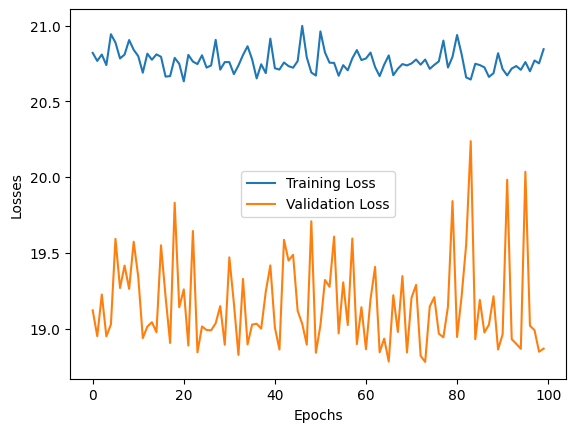

In [23]:
import matplotlib.pyplot as plt 

loss_df = pd.DataFrame({
    "Training Loss": train_lossses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"],label="Training Loss")
plt.plot(loss_df["Validation Loss"],label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()